<a href="https://colab.research.google.com/github/vtminc1000/Analisis-Sentimen/blob/main/Contohujikalimat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install vaderSentiment textblob googletrans==4.0.0-rc1 -q

In [ ]:
kalimat_negatif = "Zat yang dapat menyebabkan mutasi genetik"
kalimat_netral = "Nuklir adalah zat radioaktif yang memancarkan radiasi sesuai dengan jenisnya"
kalimat_positif = "Dapat dimanfaatkan sebagai pembangkit listrik"

In [ ]:
import pandas as pd

In [ ]:
df_uji = pd.DataFrame({
    'kategori_manual': ['Positif', 'Netral', 'Negatif'],
    'teks': [kalimat_positif, kalimat_netral, kalimat_negatif],
    'label_manual': [1, 0, -1]
})

df_uji['teks_clean'] = df_uji['teks'].apply(lambda x: str(x).lower().strip())
df_uji

,kategori_manual,teks,label_manual,teks_clean
0,Positif,Dapat dimanfaatkan sebagai pembangkit listrik,1,dapat dimanfaatkan sebagai pembangkit listrik
1,Netral,Nuklir adalah zat radioaktif yang memancarkan ...,0,nuklir adalah zat radioaktif yang memancarkan ...
2,Negatif,Zat yang dapat menyebabkan mutasi genetik,-1,zat yang dapat menyebabkan mutasi genetik


In [ ]:
positive = pd.read_csv('positive.tsv.txt', sep='\t')
negative = pd.read_csv('negative.tsv.txt', sep='\t')

lexicon_df = pd.concat([positive, negative], ignore_index=True)
inset_dict = dict(zip(lexicon_df['word'], lexicon_df['weight']))

In [ ]:
def inset_predict(text):
    score = 0
    words = str(text).split()

    for word in words:
        if word in inset_dict:
            score += inset_dict[word]

    if score > 0:
        return 1
    elif score < 0:
        return -1
    else:
        return 0

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def indobert_predict(text):
    result = classifier(str(text))[0]
    label = result['label'].lower()

    if label == 'negative':
        return -1
    elif label == 'neutral':
        return 0
    else:
        return 1

In [ ]:
!pip install googletrans==4.0.0-rc1 -q

In [ ]:
!pip install deep-translator vaderSentiment textblob -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def translate_text(text):
    try:
        return GoogleTranslator(source='id', target='en').translate(str(text))
    except:
        return str(text)

In [ ]:
def vader_predict(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 1
    elif score <= -0.05:
        return -1
    else:
        return 0

def textblob_predict(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return 1
    elif polarity < 0:
        return -1
    else:
        return 0

In [ ]:
df_uji['teks_en'] = df_uji['teks_clean'].apply(translate_text)
df_uji['vader'] = df_uji['teks_en'].apply(vader_predict)
df_uji['textblob'] = df_uji['teks_en'].apply(textblob_predict)

df_uji

,kategori_manual,teks,label_manual,teks_clean,teks_en,vader,textblob
0,Positif,Dapat dimanfaatkan sebagai pembangkit listrik,1,dapat dimanfaatkan sebagai pembangkit listrik,can be used as a power generator,0,0
1,Netral,Nuklir adalah zat radioaktif yang memancarkan ...,0,nuklir adalah zat radioaktif yang memancarkan ...,Nuclear is a radioactive substance that emits ...,0,0
2,Negatif,Zat yang dapat menyebabkan mutasi genetik,-1,zat yang dapat menyebabkan mutasi genetik,substances that can cause genetic mutations,0,0


In [ ]:
df_uji['inset'] = df_uji['teks_clean'].apply(inset_predict)
df_uji['indobert'] = df_uji['teks_clean'].apply(indobert_predict)

In [ ]:
df_uji

,kategori_manual,teks,label_manual,teks_clean,teks_en,vader,textblob,inset,indobert
0,Positif,Dapat dimanfaatkan sebagai pembangkit listrik,1,dapat dimanfaatkan sebagai pembangkit listrik,can be used as a power generator,0,0,-1,0
1,Netral,Nuklir adalah zat radioaktif yang memancarkan ...,0,nuklir adalah zat radioaktif yang memancarkan ...,Nuclear is a radioactive substance that emits ...,0,0,-1,0
2,Negatif,Zat yang dapat menyebabkan mutasi genetik,-1,zat yang dapat menyebabkan mutasi genetik,substances that can cause genetic mutations,0,0,-1,0


In [ ]:
df_plot = df_uji[['kategori_manual', 'label_manual', 'inset', 'indobert', 'vader', 'textblob']].copy()
df_plot = df_plot.set_index('kategori_manual')
df_plot

,label_manual,inset,indobert,vader,textblob
kategori_manual,,,,,
Positif,1,-1,0,0,0
Netral,0,-1,0,0,0
Negatif,-1,-1,0,0,0


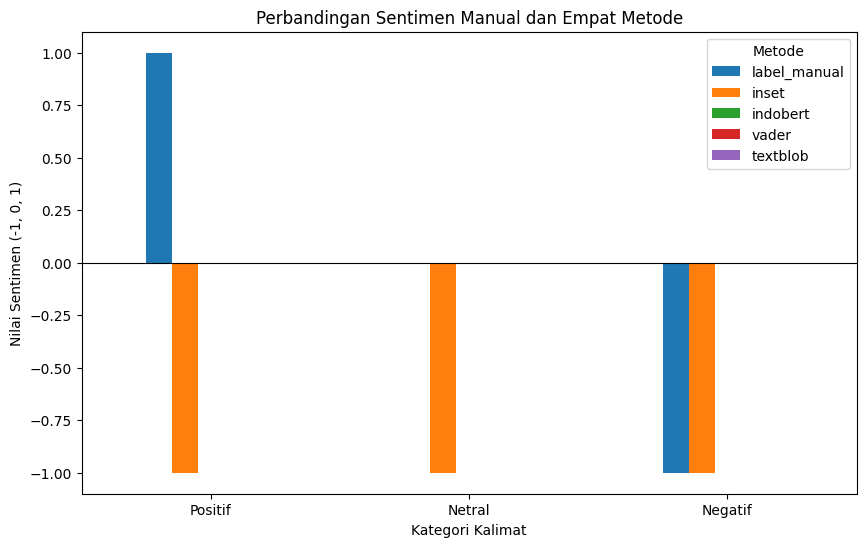

In [ ]:
import matplotlib.pyplot as plt

ax = df_plot.plot(kind='bar', figsize=(10,6))

plt.title('Perbandingan Sentimen Manual dan Empat Metode')
plt.xlabel('Kategori Kalimat')
plt.ylabel('Nilai Sentimen (-1, 0, 1)')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Metode')

plt.show()

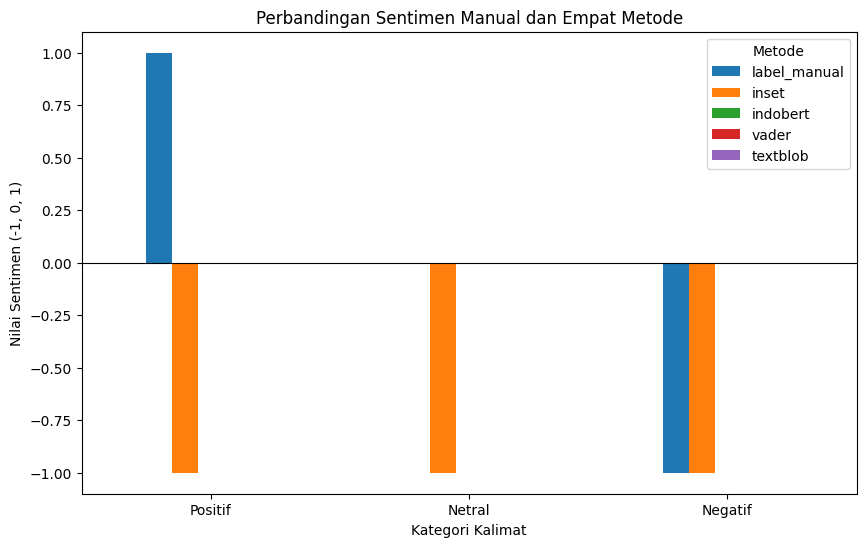

In [ ]:
ax = df_plot.plot(kind='bar', figsize=(10,6))

plt.title('Perbandingan Sentimen Manual dan Empat Metode')
plt.xlabel('Kategori Kalimat')
plt.ylabel('Nilai Sentimen (-1, 0, 1)')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Metode')

plt.savefig('grafik_perbandingan_3_kalimat.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

df_uji.to_excel('hasil_perbandingan_3_kalimat.xlsx', index=False)

files.download('hasil_perbandingan_3_kalimat.xlsx')
files.download('grafik_perbandingan_3_kalimat.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_uji['inset'] = df_uji['teks_clean'].apply(inset_predict)
df_uji['indobert'] = df_uji['teks_clean'].apply(indobert_predict)
df_uji

,kategori_manual,teks,label_manual,teks_clean,teks_en,vader,textblob,inset,indobert
0,Positif,Dapat dimanfaatkan sebagai pembangkit listrik,1,dapat dimanfaatkan sebagai pembangkit listrik,can be used as a power generator,0,0,-1,0
1,Netral,Nuklir adalah zat radioaktif yang memancarkan ...,0,nuklir adalah zat radioaktif yang memancarkan ...,Nuclear is a radioactive substance that emits ...,0,0,-1,0
2,Negatif,Zat yang dapat menyebabkan mutasi genetik,-1,zat yang dapat menyebabkan mutasi genetik,substances that can cause genetic mutations,0,0,-1,0
